Loaded data shape: (25328, 33)
Number of channels: 33
Trimmed to 32 channels (0-31): (25328, 32)


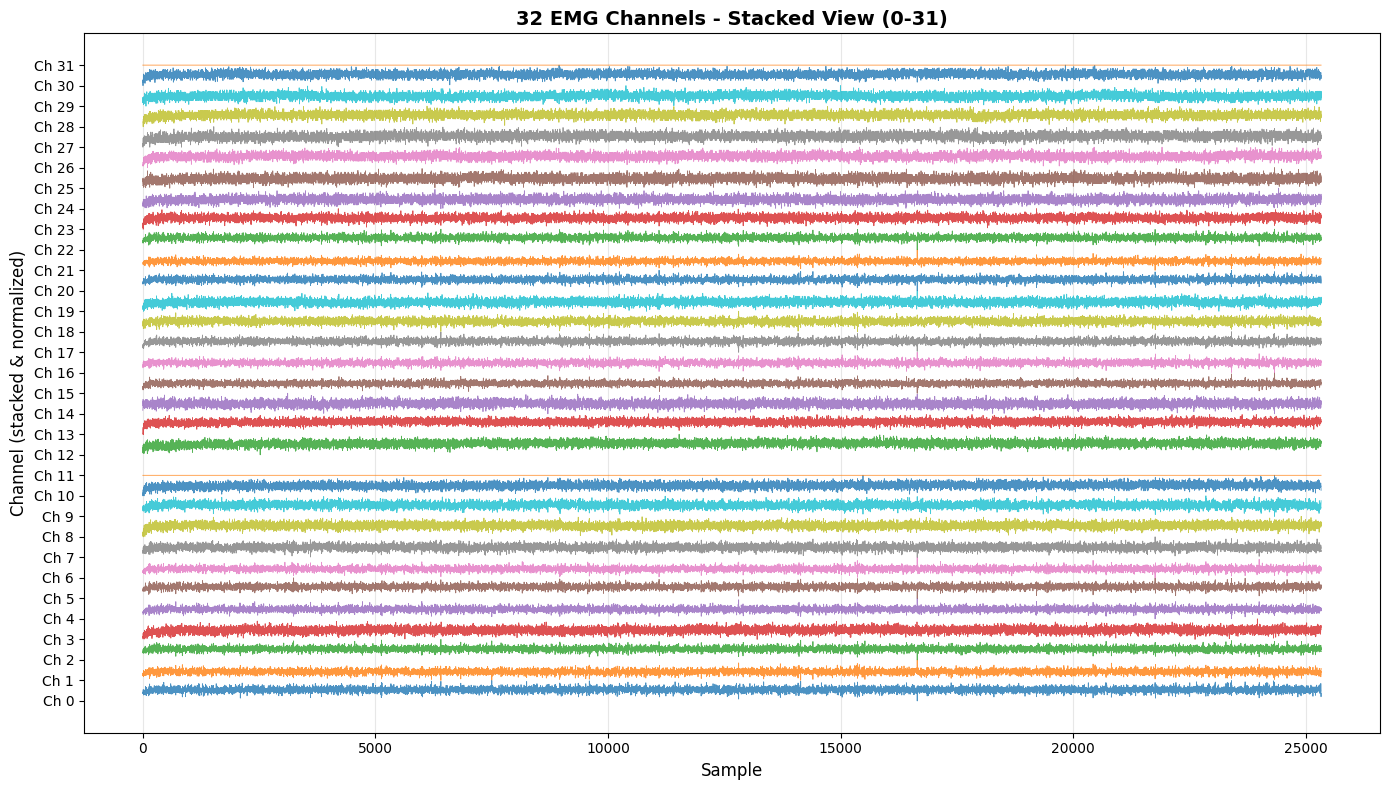

/tmp/ipykernel_24719/3169948160.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


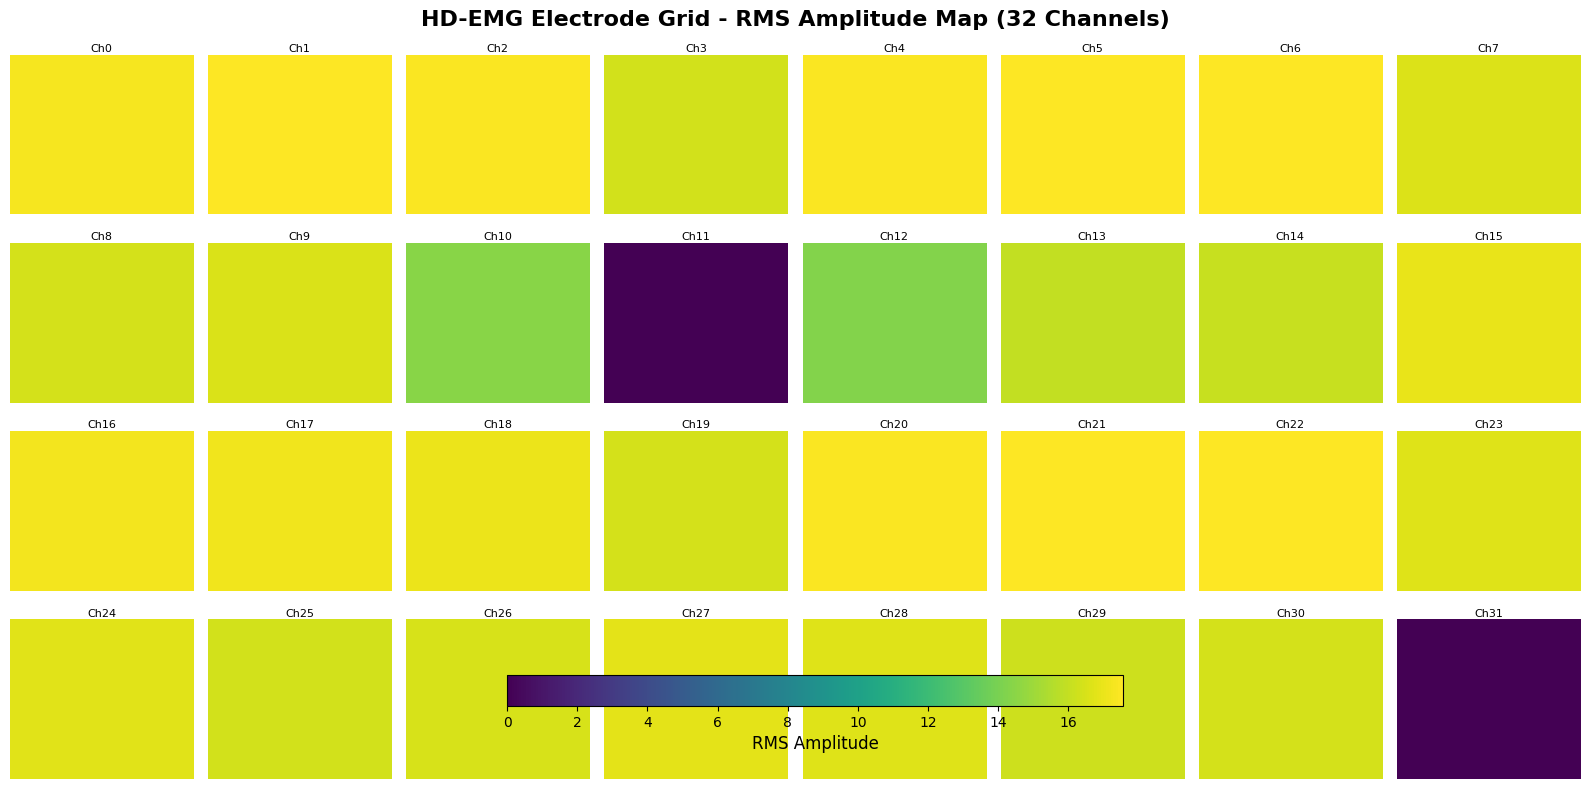

/tmp/ipykernel_24719/3169948160.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


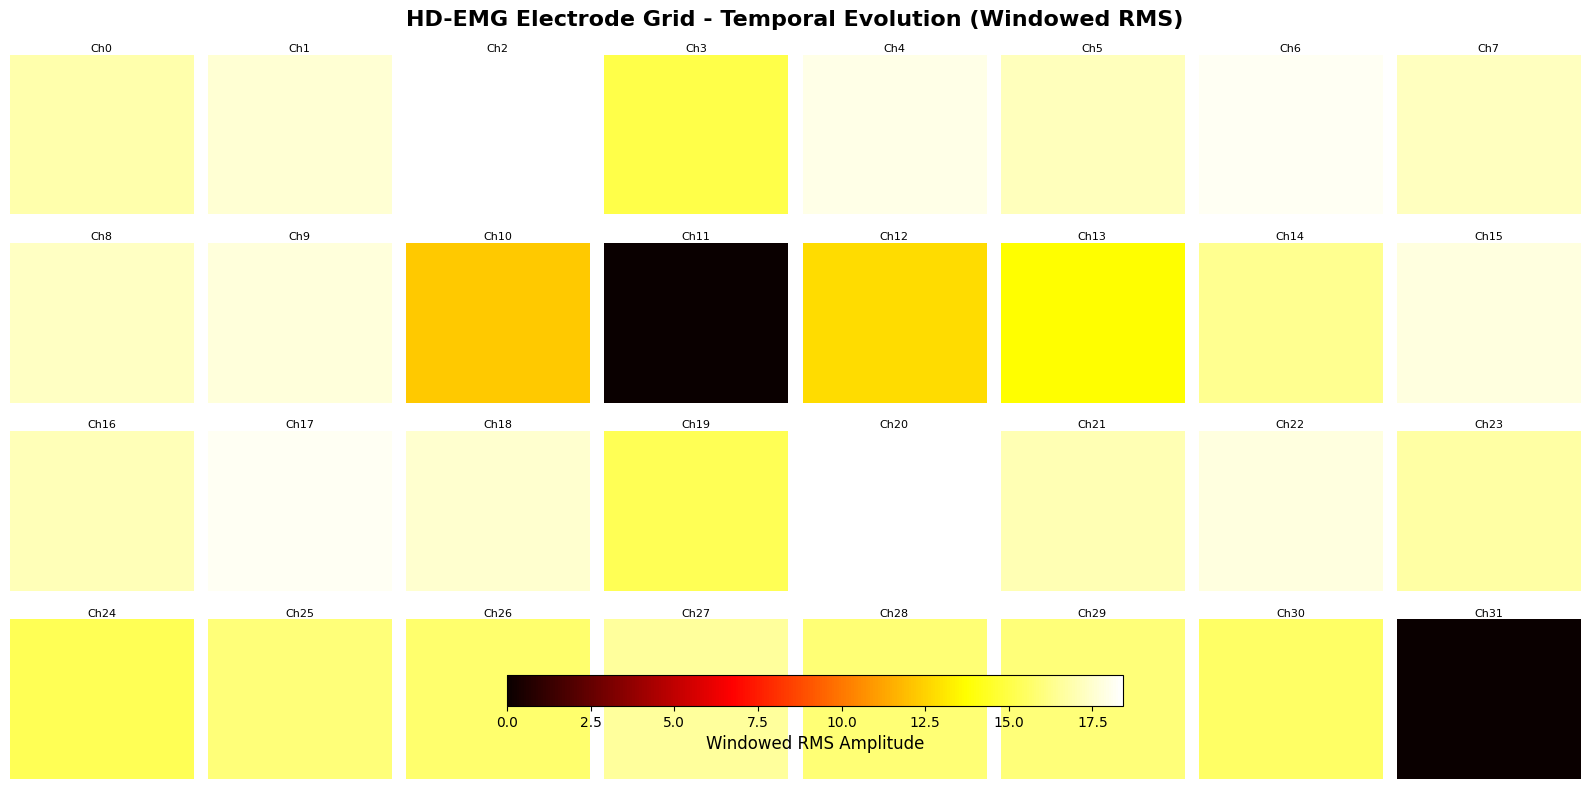

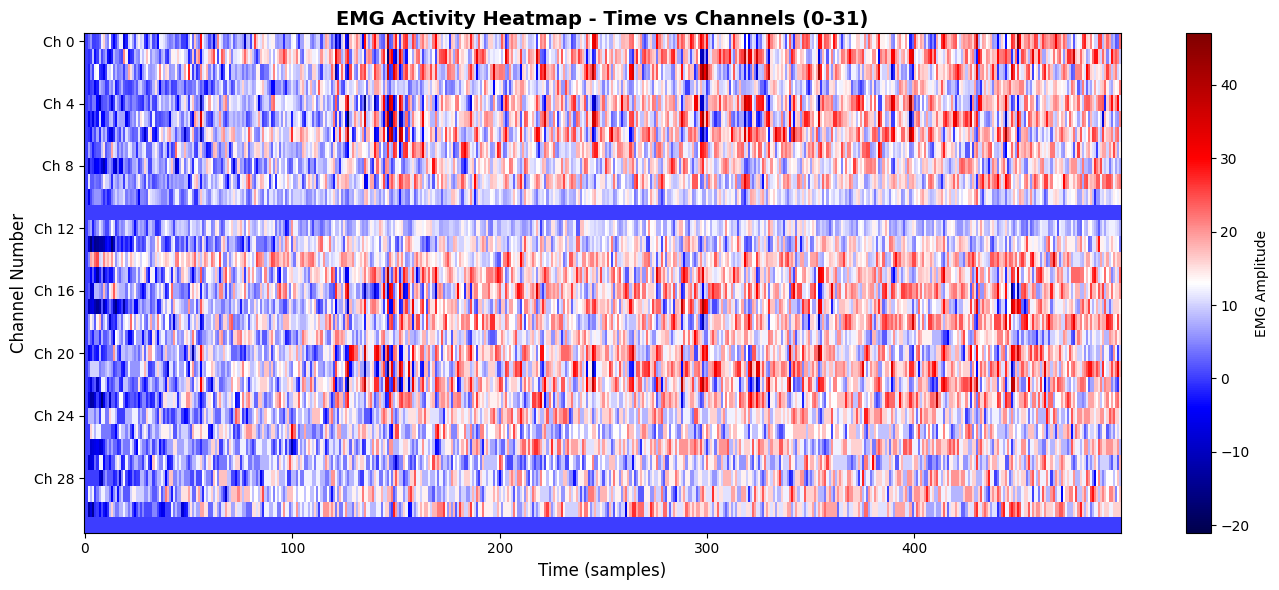

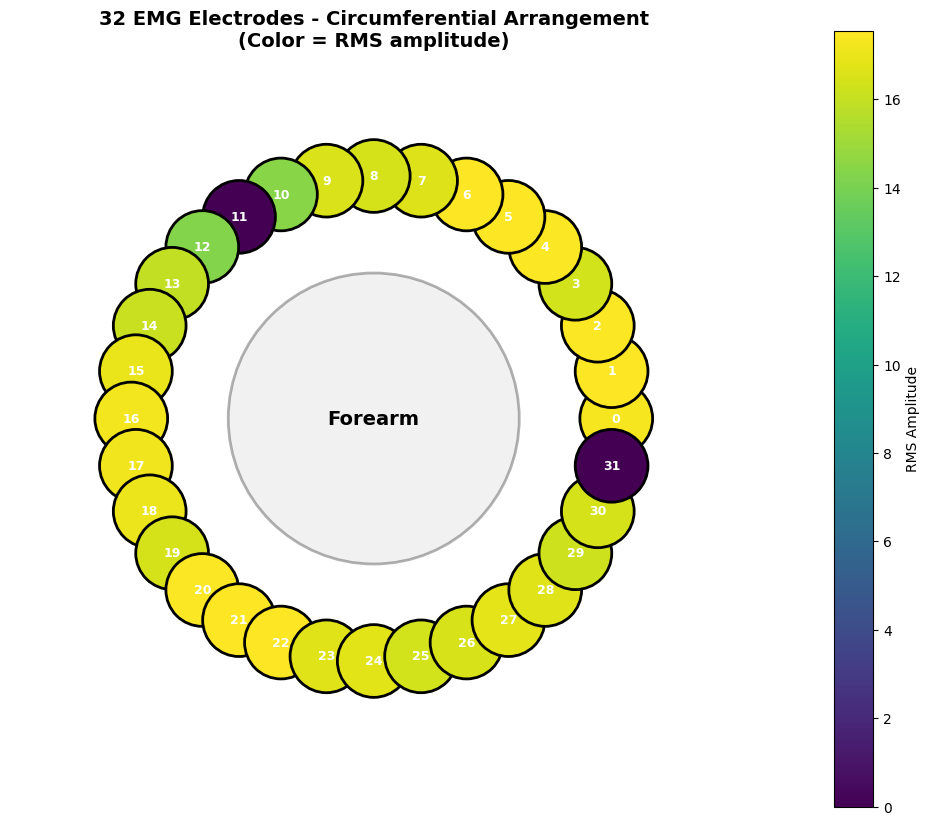


Data exported to 'emg_data_32channels.csv' with shape (25328, 32)
RMS values per channel:
[17.342447 17.506418 17.454279 16.342302 17.47096  17.558176 17.552555
 16.624935 16.395397 16.567516 14.412181  0.       14.266647 15.954244
 16.116423 16.9507   17.251139 17.150438 17.018757 16.444775 17.425133
 17.50428  17.500242 16.728548 16.74646  16.367289 16.500374 16.828262
 16.674767 16.216846 16.437155  0.      ]
   Channel_0  Channel_1  Channel_2  Channel_3  Channel_4  Channel_5  \
0        0.0        0.0        0.0        0.0        0.0        0.0   
1        0.0        0.0        0.0        0.0        0.0        0.0   
2        3.0       -1.0       -2.0       -2.0        2.0       -4.0   
3        6.0        0.0        5.0        0.0        0.0       -1.0   
4        0.0        9.0        0.0        1.0        4.0       -6.0   

   Channel_6  Channel_7  Channel_8  Channel_9  ...  Channel_22  Channel_23  \
0        0.0        0.0        0.0        0.0  ...         0.0         0.0   


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from matplotlib import animation
from IPython.display import HTML

# Load EMG data from session file
session_file = Path("/home/fire/Documents/gitwork/EMG_Exo/md-emg-python/data/healthy/S0/emg_logs/session_00.npy")

# Load all arrays from the npy file
arrays = []
with open(session_file, 'rb') as f:
    while True:
        try:
            arrays.append(np.load(f, allow_pickle=False))
        except (ValueError, EOFError):
            break

# Concatenate all buffers into single array (time x channels)
data = np.concatenate(arrays, axis=0)
print(f"Loaded data shape: {data.shape}")
print(f"Number of channels: {data.shape[1] if data.ndim > 1 else 1}")

# Ensure we only use channels 0-31 (first 32 channels)
if data.ndim > 1 and data.shape[1] > 32:
    data = data[:, :32]
    print(f"Trimmed to 32 channels (0-31): {data.shape}")

n_channels = data.shape[1] if data.ndim > 1 else 1

# ============ Plot 1: Stacked line plot (like streaming_gui.py) ============
fig, ax = plt.subplots(figsize=(14, 8))

# Normalize and stack each channel (similar to streaming_gui)
x_plot = np.arange(data.shape[0])
for ch in range(n_channels):
    channel_data = data[:, ch]
    minimum = np.min(channel_data)
    maximum = np.max(channel_data)
    # Normalize to [0,1] and offset by channel number for stacking
    normed = (channel_data - minimum) / (maximum - minimum + 1e-9) + ch
    ax.plot(x_plot, normed, label=f'Ch {ch}', alpha=0.8, linewidth=0.6)

ax.set_xlabel("Sample", fontsize=12)
ax.set_ylabel("Channel (stacked & normalized)", fontsize=12)
ax.set_title(f"32 EMG Channels - Stacked View (0-{n_channels-1})", fontsize=14, fontweight='bold')
ax.set_yticks(range(n_channels))
ax.set_yticklabels([f'Ch {i}' for i in range(n_channels)])
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# ============ Plot 2: HD-EMG Electrode Grid Heatmap ============
# Create a 2D grid layout for 32 channels arranged as electrode array around forearm
# Typical HD-EMG sleeve layout: 4 rows × 8 columns or 8 rows × 4 columns
# We'll use 4 rows × 8 columns to represent circumferential arrangement

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle("HD-EMG Electrode Grid - RMS Amplitude Map (32 Channels)", fontsize=16, fontweight='bold')

# Calculate RMS for each channel
rms_values = np.sqrt(np.mean(data**2, axis=0))

# Reshape channels into 4×8 grid
grid_shape = (4, 8)
channel_grid = np.arange(32).reshape(grid_shape)

# Create heatmap for each electrode position
vmin, vmax = rms_values.min(), rms_values.max()

for row in range(grid_shape[0]):
    for col in range(grid_shape[1]):
        ch_idx = channel_grid[row, col]
        ax = axes[row, col]
        
        # Plot RMS as colored square
        im = ax.imshow([[rms_values[ch_idx]]], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_title(f'Ch{ch_idx}', fontsize=8, pad=2)
        ax.axis('off')

# Add colorbar
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', pad=0.05, fraction=0.05)
cbar.set_label('RMS Amplitude', fontsize=12)
plt.tight_layout()
plt.show()

# ============ Plot 3: Time-evolving HD-EMG Heatmap Grid ============
# Show how EMG spatial pattern evolves over time
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle("HD-EMG Electrode Grid - Temporal Evolution (Windowed RMS)", fontsize=16, fontweight='bold')

# Select a representative time window (e.g., 500 samples)
window_size = 500
window_start = min(1000, data.shape[0] - window_size)
window_data = data[window_start:window_start+window_size, :]

# Calculate windowed RMS
window_rms = np.sqrt(np.mean(window_data**2, axis=0))

vmin_win, vmax_win = window_rms.min(), window_rms.max()

for row in range(grid_shape[0]):
    for col in range(grid_shape[1]):
        ch_idx = channel_grid[row, col]
        ax = axes[row, col]
        
        # Plot windowed RMS
        im = ax.imshow([[window_rms[ch_idx]]], cmap='hot', vmin=vmin_win, vmax=vmax_win, aspect='auto')
        ax.set_title(f'Ch{ch_idx}', fontsize=8, pad=2)
        ax.axis('off')

cbar = fig.colorbar(im, ax=axes, orientation='horizontal', pad=0.05, fraction=0.05)
cbar.set_label('Windowed RMS Amplitude', fontsize=12)
plt.tight_layout()
plt.show()

# ============ Plot 4: Temporal Heatmap (Time × Channels) ============
# Traditional heatmap showing activity across all channels over time
n_samples_display = min(500, data.shape[0])
heatmap_data = data[:n_samples_display, :]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(heatmap_data.T, aspect='auto', cmap='seismic', interpolation='nearest')
ax.set_xlabel("Time (samples)", fontsize=12)
ax.set_ylabel("Channel Number", fontsize=12)
ax.set_title(f"EMG Activity Heatmap - Time vs Channels (0-{n_channels-1})", fontsize=14, fontweight='bold')
ax.set_yticks(range(0, n_channels, 4))
ax.set_yticklabels([f'Ch {i}' for i in range(0, n_channels, 4)])
cbar = plt.colorbar(im, ax=ax, label='EMG Amplitude')
plt.tight_layout()
plt.show()

# ============ Plot 5: Circular electrode sleeve visualization ============
fig, ax = plt.subplots(figsize=(10, 10))

# Arrange 32 electrodes in circular pattern (simulating sleeve around arm)
n_electrodes = 32
angles = np.linspace(0, 2*np.pi, n_electrodes, endpoint=False)
radius = 2.0

positions = []
for i in range(n_electrodes):
    x = radius * np.cos(angles[i])
    y = radius * np.sin(angles[i])
    positions.append((x, y))

# Use RMS for color coding
rms_normalized = (rms_values - rms_values.min()) / (rms_values.max() - rms_values.min() + 1e-8)

# Draw arm (center circle)
arm_circle = patches.Circle((0, 0), radius * 0.6, fill=True, facecolor='lightgray', edgecolor='black', linewidth=2, alpha=0.3)
ax.add_patch(arm_circle)
ax.text(0, 0, 'Forearm', ha='center', va='center', fontsize=14, fontweight='bold')

# Plot electrodes
for i, (x, y) in enumerate(positions):
    color_intensity = rms_normalized[i]
    circle = patches.Circle((x, y), 0.3, color=plt.cm.viridis(color_intensity), ec='black', linewidth=2)
    ax.add_patch(circle)
    ax.text(x, y, f'{i}', ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f"32 EMG Electrodes - Circumferential Arrangement\n(Color = RMS amplitude)", fontsize=14, fontweight='bold')

# Colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=rms_values.min(), vmax=rms_values.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.8, label='RMS Amplitude')
plt.tight_layout()
plt.show()

# ============ Export to CSV ============
df = pd.DataFrame(data, columns=[f'Channel_{i}' for i in range(n_channels)])
df.to_csv("emg_data_32channels.csv", index=False)
print(f"\nData exported to 'emg_data_32channels.csv' with shape {df.shape}")
print(f"RMS values per channel:\n{rms_values}")
print(df.head())
